#Top

[![Open in GitHub](https://img.shields.io/badge/Open%20Folder%20in-GitHub-181717?logo=github&logoColor=white)](https://github.com/lindsayalexandra14/ds_portfolio/tree/main/1_projects/statistical_analysis/regression_discontinuity)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lindsayalexandra14/ds_portfolio/blob/main/1_projects/statistical_analysis/regression_discontinuity/rdd_shopping_r_google_colab.ipynb)

#Regression Discontinuity for Shopping Data

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Regression%20Discontinuity%20for%20Shopping%20Data.png)

**test**
*   This regression discontinuity analysis on online shopping data tests if there is a significant causal effect of receiving free shipping on the first order on the number of additional orders in their next year. The running variable is the first order amount, which has a natural cutoff of $125 for receiving the treatment of free shipping. The sample size is 200K customers.

**result**
*  It was established that there is a significant causal effect of ~6 additional orders from receiving free shipping on the first order.

**recommendation**
*  In this case, I recommend implementing a free shipping policy on ALL first orders, given its impact.

# Setup

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Setup.png)

## Install Packages

In [ ]:
install.packages("stargazer")
install.packages("ggplot2")
install.packages("car")
install.packages("broom")
install.packages("ggthemes")
install.packages("showtext")
install.packages("dplyr")
install.packages("rdrobust")
install.packages("rddensity")

## Load Libraries

In [ ]:
library(stargazer)
library(ggthemes)
library(ggplot2)
library(dplyr)
library(showtext)
library(rdrobust)
library(rddensity)
library(car)
library(broom)

#Data

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Data.png)

## Simulate Data

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Simulate%20Data.png)

Simluate shopping data with fields: Customer ID, 1st Order Amount, Orders in Next Year, Free Shipping (on 1st order):

In [ ]:
set.seed(20)

# Parameters
n_customers <- 200000         # Total number of customers
cutoff <- 125                 # Free shipping (on first order) threshold
effect_orders <- 6            # Extra orders due to free shipping
noise_sd_orders <- 1          # Random noise in orders

# Define products and their price ranges
apparel_products <- list(
  "T-Shirt" = c(25, 75),
  "Jeans"   = c(65, 200),
  "Jacket"  = c(45, 130),
  "Sweater" = c(60, 150),
  "Shoes"   = c(35, 200),
  "Hat"     = c(15, 75),
  "Dress"   = c(45, 150),
  "Socks"   = c(10, 30),
  "Shorts"  = c(45, 100)
)

# Extract product names
product_names <- names(apparel_products)

# List to store each customer's data
customer_data <- vector("list", n_customers)

# Loop over each customer
for (customer_id in 1:n_customers) {

  # Randomly choose number of items in first order (1–3)
  num_items <- sample(1:3, 1)

  # Randomly select products for the basket
  chosen_products <- sample(product_names, num_items, replace = TRUE)

  # Assign a random price to each chosen product
  prices <- sapply(chosen_products, function(prod) {
    runif(1, apparel_products[[prod]][1], apparel_products[[prod]][2])
  })
  # Selects the lower and upper bounds of the product's price range
  # Generates random numbers from a uniform distribution

  # Compute total purchase amount for first order
  purchase_amount <- sum(prices)

  # Determine free shipping eligibility (1 = yes, 0 = no)
  first_order_free_shipping <- as.integer(purchase_amount >= cutoff)

  # Base number of orders: random component + scaled purchase amount
  base_orders <- runif(1, 0, 20) + 0.14 * purchase_amount / 10

  # Total orders in first year: add free shipping effect + random noise
  next_orders <- base_orders + effect_orders * first_order_free_shipping + rnorm(1, 0, noise_sd_orders)

  # Ensure orders are non-negative integers
  next_orders <- round(pmax(0, next_orders))

  # Store the customer's simulated data in a data.frame
  customer_data[[customer_id]] <- data.frame(
    customer_id = customer_id,
    first_order_amount = purchase_amount,
    addtl_orders_first_year = next_orders
  )
}

# Combine all customers into a single dataframe
df_all_data <- do.call(rbind, customer_data)

# Add categorical free_shipping variable ("yes"/"no")
df_all_data <- df_all_data %>%
  mutate(first_order_free_shipping = ifelse(first_order_amount >= cutoff, "yes", "no"))


Add age field as a covariate:

In [ ]:
# Generate 100 random ages between 18 and 75
age <- sample(18:75, size = n_customers, replace = TRUE)

head(age)


[1] 73 65 69 61 53 56

In [ ]:
df_all_data<- cbind(df_all_data, age)

## View Data

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/View%20Data.png)

Display number of customers in each free shipping group:

In [ ]:
table(df_all_data$first_order_free_shipping)


    no    yes 
 78546 121454 

Preview data:

In [ ]:
head(df_all_data)

,customer_id,first_order_amount,addtl_orders_first_year,first_order_free_shipping,age
,<int>,<dbl>,<dbl>,<chr>,<int>
1,1,106.93699,2,no,73
2,2,55.58302,9,no,65
3,3,135.03639,9,yes,69
4,4,18.84516,13,no,61
5,5,129.12330,18,yes,53
6,6,101.95486,17,no,56


View summary statistics:

In [ ]:
summary(df_all_data)

  customer_id     first_order_amount addtl_orders_first_year
 Min.   :     1   Min.   : 10.00     Min.   : 0.00          
 1st Qu.: 50001   1st Qu.: 89.16     1st Qu.:11.00          
 Median :100000   Median :150.50     Median :16.00          
 Mean   :100000   Mean   :161.71     Mean   :15.91          
 3rd Qu.:150000   3rd Qu.:222.28     3rd Qu.:21.00          
 Max.   :200000   Max.   :579.46     Max.   :34.00          
 first_order_free_shipping      age       
 Length:200000             Min.   :18.00  
 Class :character          1st Qu.:32.00  
 Mode  :character          Median :46.00  
                           Mean   :46.49  
                           3rd Qu.:61.00  
                           Max.   :75.00  

## Visualize Data

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Visualize%20Data.png)

View distributions of outcome & running variables as histograms:

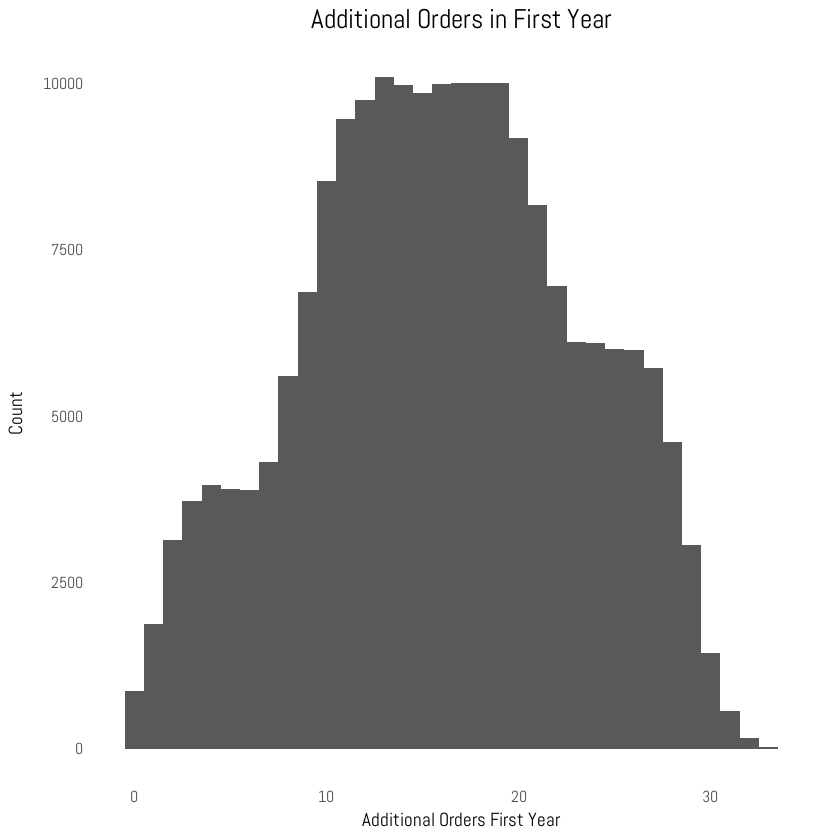

In [ ]:
font_add_google("Abel", "abel")
showtext_auto()

ggplot(df_all_data, aes(x = addtl_orders_first_year)) +
  geom_histogram(bins = 35) +
  labs(title = "Additional Orders in First Year",
       x = "Additional Orders First Year",
       y = "Count") +
theme_minimal() +
theme(panel.grid.major = element_blank(),
      panel.grid.minor = element_blank())  +
theme(
  plot.title = element_text(hjust = 0.5, size = 20, face = "bold", family = "abel"),
  axis.title.x = element_text(size = 14, face = "bold", family = "abel"),
  axis.title.y = element_text(size = 14, face = "bold", family = "abel"),
  legend.position = "top",
  legend.title = element_text(size = 14, face = "bold", family = "abel"),
  legend.text = element_text(size = 12, family = "abel"),
  axis.text.x = element_text(size = 12, family = "abel"),
  axis.text.y = element_text(size = 12, family = "abel")
)


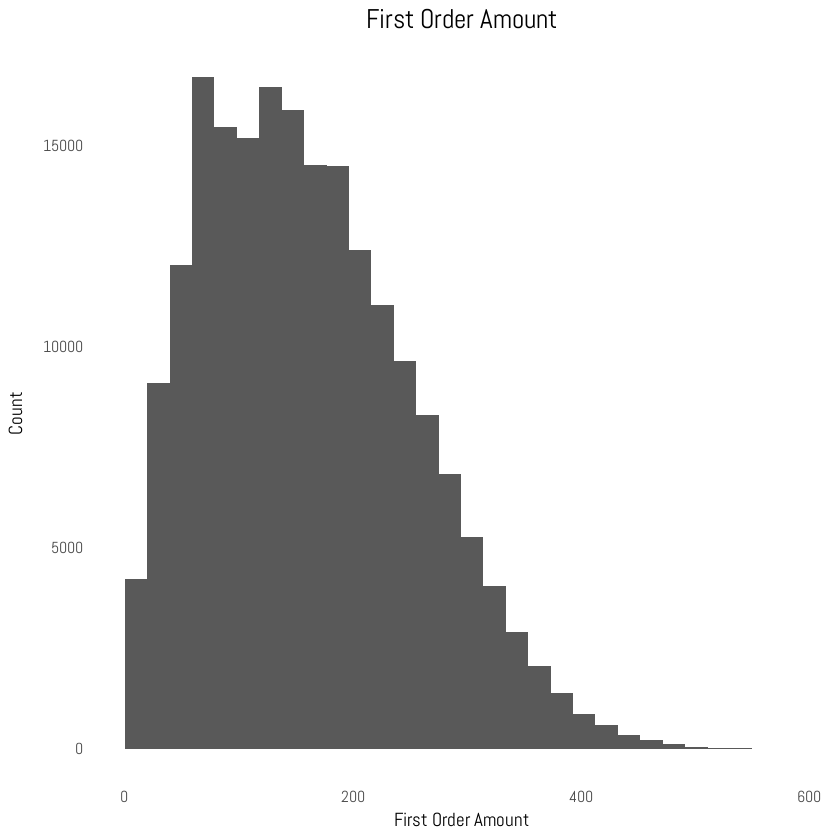

In [ ]:
font_add_google("Abel", "abel")
showtext_auto()

ggplot(df_all_data, aes(x = first_order_amount)) +
  geom_histogram(bins = 30) +
  labs(title = "First Order Amount",
       x = "First Order Amount",
       y = "Count") +
theme_minimal() +
theme(panel.grid.major = element_blank(),
      panel.grid.minor = element_blank())  +
theme(
  plot.title = element_text(hjust = 0.5, size = 20, face = "bold", family = "abel"),
  axis.title.x = element_text(size = 14, face = "bold", family = "abel"),
  axis.title.y = element_text(size = 14, face = "bold", family = "abel"),
  legend.position = "top",
  legend.title = element_text(size = 14, face = "bold", family = "abel"),
  legend.text = element_text(size = 12, family = "abel"),
  axis.text.x = element_text(size = 12, family = "abel"),
  axis.text.y = element_text(size = 12, family = "abel")
)


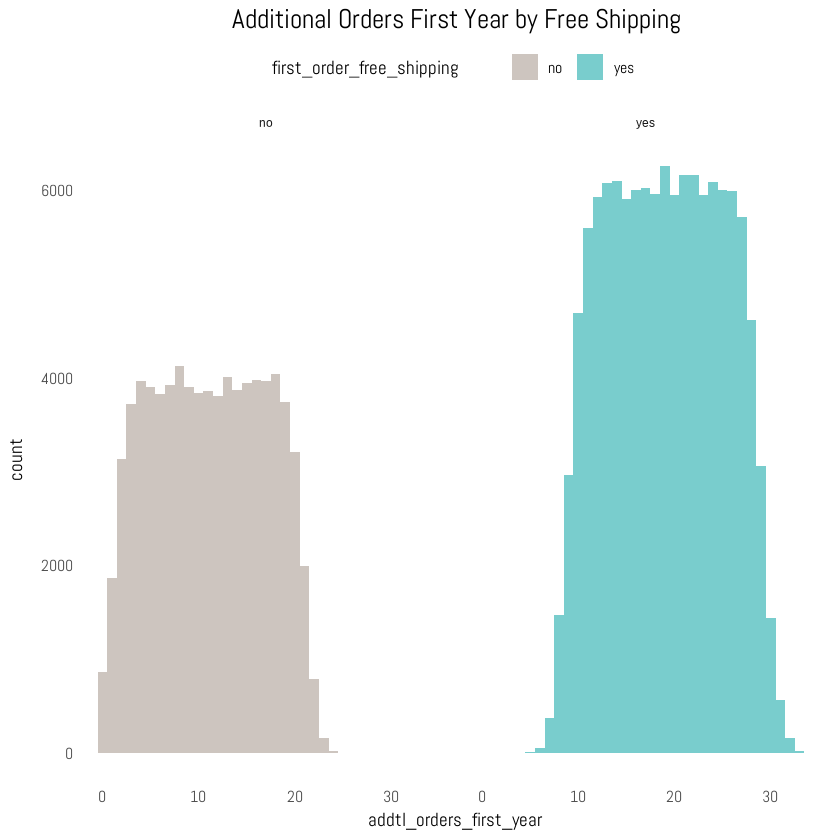

In [ ]:
ggplot(df_all_data, aes(x = addtl_orders_first_year, fill = first_order_free_shipping)) +
  geom_histogram(position = "dodge", bins = 35) +
  facet_wrap(~ first_order_free_shipping) +
  labs(title = "Additional Orders First Year by Free Shipping") +
scale_fill_manual(values = c("seashell3", "darkslategray3")) +
theme_minimal() +
theme(panel.grid.major = element_blank(),
      panel.grid.minor = element_blank())  +
theme(
  plot.title = element_text(hjust = 0.5, size = 20, face = "bold", family = "abel"),
  axis.title.x = element_text(size = 14, face = "bold", family = "abel"),
  axis.title.y = element_text(size = 14, face = "bold", family = "abel"),
  legend.position = "top",
  legend.title = element_text(size = 14, face = "bold", family = "abel"),
  legend.text = element_text(size = 12, family = "abel"),
  axis.text.x = element_text(size = 12, family = "abel"),
  axis.text.y = element_text(size = 12, family = "abel")
)


#RDD Model

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/RDD%20Model.png)

Run rdrobust to calculate Optimal Bandwidth, Point Estimate & 95% Confidence Interval for Regression Discontinuity using automatic bandwidth selection. It runs local linear regression (p=1), (note: "polynomial" is just used for the bias correction):

In [ ]:
rd_res <- rdrobust(y = df_all_data$addtl_orders_first_year, x = df_all_data$first_order_amount, c = cutoff,p=1)
summary(rd_res)

Sharp RD estimates using local polynomial regression.

Number of Obs.               200000
BW type                       mserd
Kernel                   Triangular
VCE method                       NN

Number of Obs.                78546       121454
Eff. Number of Obs.           37249        37383
Order est. (p)                    1            1
Order bias  (q)                   2            2
BW est. (h)                  47.274       47.274
BW bias (b)                  71.409       71.409
rho (h/b)                     0.662        0.662
Unique Obs.                   78546       121454

                   Point    Robust Inference
                Estimate         z     P>|z|      [ 95% C.I. ]       
---------------------------------------------------------------------
     RD Effect     6.022    54.059     0.000     [5.804 , 6.241]     


Display bandwidths & bias separately:

In [ ]:
rd_res$bws

,left,right
h,47.27355,47.27355
b,71.40938,71.40938


Assign left and right bandwidth for later use when limiting bandwidth:

In [ ]:
left_bw<-rd_res$bws["h", "left"]

In [ ]:
right_bw<-rd_res$bws["h", "right"]

## Optimal Bandwidth

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Optimal%20Bandwidth.png)

Narrow to optimal bandwidth from rdrobust above to customers with first orders within ~47 dollars around the 125 dollar cutoff & ensure balanced sample sizes:

In [ ]:
df<-df_all_data %>%
  filter(first_order_amount >= cutoff - left_bw,
         first_order_amount <= cutoff + right_bw)

table(df$first_order_free_shipping)


   no   yes 
37249 37383 

Show histogram of balanced sample sizes. Shows they are relatively balanced with no discontinuity or dip at the cutoff:

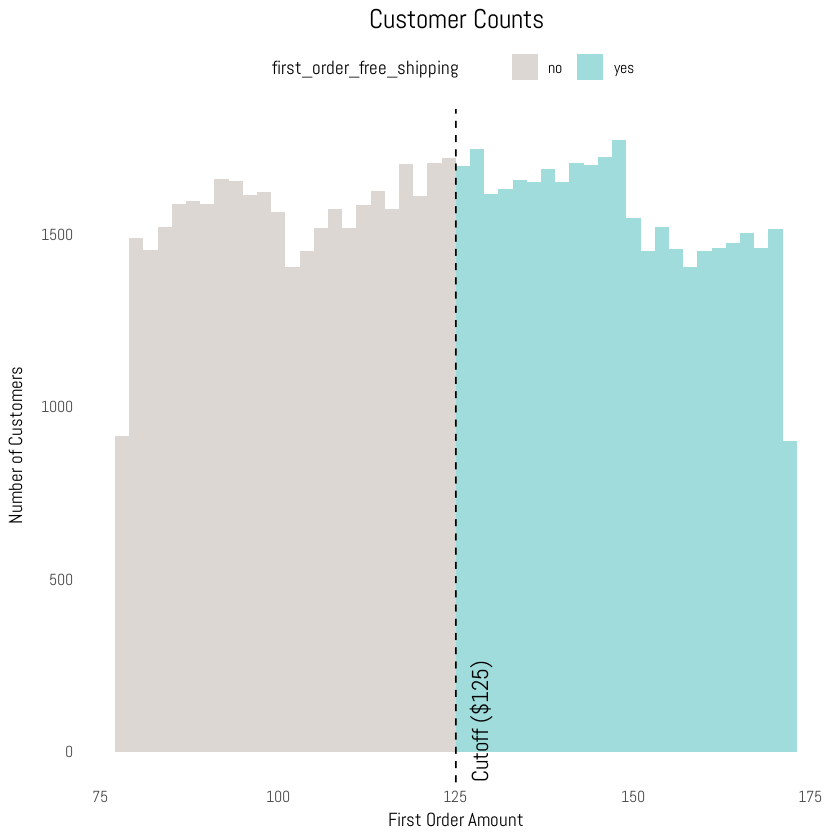

In [ ]:
suppressWarnings({
  font_add_google("Abel", "abel")
  showtext_auto()

  ggplot(df, aes(x = first_order_amount, fill = first_order_free_shipping)) +
    geom_histogram(binwidth = 2, alpha = 0.7, position = "identity") +
    geom_vline(xintercept = cutoff, color = "black", linetype = "dashed") +
    labs(title = "Customer Counts",
         x = "First Order Amount",
         y = "Number of Customers") +
    scale_fill_manual(values = c("seashell3", "darkslategray3")) +
    theme_minimal() +
    annotate(
      "text", x = cutoff, y = max(df$y, na.rm = TRUE), label = "Cutoff ($125)", angle = 90,
      vjust = 2, hjust = 0, size = 6, family = "abel", fontface = "bold"
    ) +
    theme(panel.grid.major = element_blank(),
          panel.grid.minor = element_blank()) +
    theme(
      plot.title = element_text(hjust = 0.5, size = 20, face = "bold", family = "abel"),
      axis.title.x = element_text(size = 14, face = "bold", family = "abel"),
      axis.title.y = element_text(size = 14, face = "bold", family = "abel"),
      legend.position = "top",
      legend.title = element_text(size = 14, face = "bold", family = "abel"),
      legend.text = element_text(size = 12, family = "abel"),
      axis.text.x = element_text(size = 12, family = "abel"),
      axis.text.y = element_text(size = 12, family = "abel")
    )
})


## RDD Plot

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/RDD%20Plot.png)

Create bins to visualize the regression(s) better. Will show a mean for bins of 5 dollar increments. Reduces noise in the scatterplot to show the regression more clearly with bigger points.

In [ ]:
# Create bins
df <- df %>%
  mutate(bin = cut(first_order_amount, breaks = seq(0, max(first_order_amount) + 5, by = 5)))

In [ ]:
# Create bin means
bin_means <- df %>%
  group_by(bin, first_order_free_shipping) %>%
  summarise(
    avg_purchase = mean(first_order_amount),
    avg_orders = mean(addtl_orders_first_year),
    .groups = "drop"
  )

Assign variables for regression discontinuity model:

In [ ]:
# Running variable, has cutoff
df$x=df$first_order_amount

# Response variable - trying to establish significance of this vs. treatment
df$y=df$addtl_orders_first_year

# (Treatment is x after cutoff (Di=1 if X>=cutoff))

Show data with new bin field:

In [ ]:
print(head(df))

  customer_id first_order_amount addtl_orders_first_year
1           1          106.93699                       2
2           3          135.03639                       9
3           5          129.12330                      18
4           6          101.95486                      17
5           7           80.46316                      19
6           9          108.50146                       5
  first_order_free_shipping age       bin         x  y
1                        no  73 (105,110] 106.93699  2
2                       yes  69 (135,140] 135.03639  9
3                       yes  53 (125,130] 129.12330 18
4                        no  56 (100,105] 101.95486 17
5                        no  52   (80,85]  80.46316 19
6                        no  74 (105,110] 108.50146  5


Plot regression discontuinity model (with linear regression):

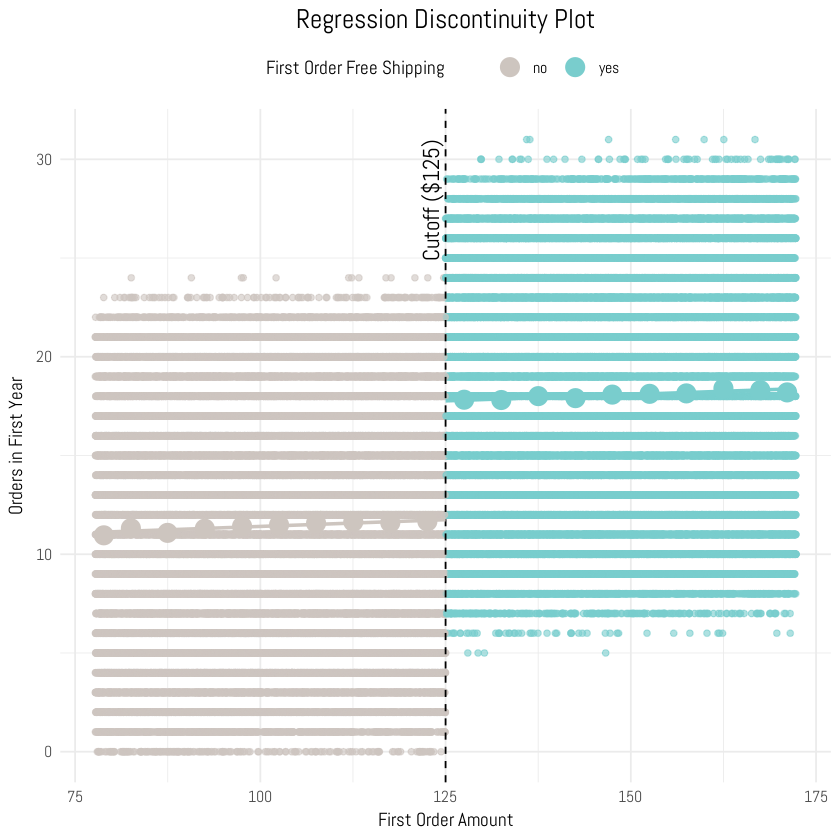

In [ ]:
cutoff_label_y <- max(df$y, na.rm = TRUE)

  ggplot(df, aes(x = x, y = y, color = factor(first_order_free_shipping))) +
    geom_point(alpha = 0.6) +
    geom_point(data = bin_means, aes(x = avg_purchase, y = avg_orders, color = first_order_free_shipping), size = 5) +
    scale_color_manual(values = c("no" = "seashell3", "yes" = "darkslategray3")) +
    geom_vline(xintercept = cutoff, linetype = "dashed", color = "black") +
    annotate(
      "text", x = cutoff, y = cutoff_label_y, label = "Cutoff ($125)", angle = 90,
      vjust = -0.4, hjust = 1, size = 6, family = "abel", fontface = "bold"
    ) +
    geom_smooth(
      data = filter(df, x < cutoff),
      mapping = aes(x = x, y = y),
      method = "lm", formula = y ~ x, se = FALSE, color = "seashell3"
    ) +
    geom_smooth(
      data = filter(df, x >= cutoff),
      mapping = aes(x = x, y = y),
      method = "lm", formula = y ~ x, se = FALSE, color = "darkslategray3"
    ) +
    labs(
      x = "First Order Amount",
      y = "Orders in First Year",
      color = "First Order Free Shipping"
    ) +
    theme_minimal() +
    theme(
      plot.title = element_text(hjust = 0.5, size = 20, face = "bold", family = "abel"),
      axis.title.x = element_text(size = 14, face = "bold", family = "abel"),
      axis.title.y = element_text(size = 14, face = "bold", family = "abel"),
      legend.position = "top",
      legend.title = element_text(size = 14, face = "bold", family = "abel"),
      legend.text = element_text(size = 12, family = "abel"),
      axis.text.x = element_text(size = 12, family = "abel"),
      axis.text.y = element_text(size = 12, family = "abel")
    ) +
    ggtitle("Regression Discontinuity Plot")


## RDD Model (manual)

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/RDD%20Model%20manual.png)

Fit regression discontinuity model (manually with linear regression):

model<-lm(y~x+treatment+x:treatment,data=df)

In [ ]:
model1<-lm(addtl_orders_first_year~first_order_amount+first_order_free_shipping+first_order_amount:first_order_free_shipping,data=df)

View model:

In [ ]:
stargazer(model1,type="text",style="aer",
          column.labels=c("Y~X+I(X>Cutoff)+X*I(X>Cutoff)"),
          dep.var.labels="Regression Discontinuity",
          omit.stat=c("f","ser","rsq","n","adj.rsq"),
          intercept.bottom=F)


                                                       Regression Discontinuity       
                                                    Y~X+I(X>Cutoff)+X*I(X>Cutoff)     
--------------------------------------------------------------------------------------
Constant                                                      10.049***               
                                                               (0.228)                
                                                                                      
first_order_amount                                             0.014***               
                                                               (0.002)                
                                                                                      
first_order_free_shippingyes                                   6.095***               
                                                               (0.403)                
                                          

Print coefficients with clearer/expanded numbers:

In [ ]:
print(coef(model1))

                                    (Intercept) 
                                  10.0489434694 
                             first_order_amount 
                                   0.0136018246 
                   first_order_free_shippingyes 
                                   6.0953882862 
first_order_amount:first_order_free_shippingyes 
                                  -0.0006212591 


Run linear hypothesis test. Because I chose to not center the cutoff to 0 for this project, the first_order_free_shippingyes coefficient alone does not equal the causal effect. The causal effect is B2+B3*cutoff, and this full term needs to have its significance tested. This test runs two models and compares their RSS (residual sum of squares). It shows that the first model performs worse which is restricted to the causal effect =0 (H0:b2+b3×cutoff=0), therefore there is strong evidence that the causal effect is not 0, meaning it is significant:

In [ ]:
cutoff <- 125
linearHypothesis(model1, c(paste0("first_order_free_shippingyes + ", cutoff, " * first_order_amount:first_order_free_shippingyes = 0")))


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,74629,2752687,NA,NA,NA,NA
2,74628,2577678,1,175008.8,5066.792,0


p-value of ~0 shows that the causal effect of the treatment at the cutoff is not 0 and is significant

## Causal Effect (manual)

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Causal%20Effect%20manual.png)

In RDD (w/ an uncentered cutoff), the causal effect (𝐵2+𝐵3∗125). It is a local average treatment effect for users right at the cutoff.

model1<-lm(orders_first_year~first_order_amount+free_shipping+first_order_amount:free_shipping,data=df)

Extract coefficient names from model:

In [ ]:
coef_names <- names(coef(model1))
print(coef_names)

[1] "(Intercept)"                                    
[2] "first_order_amount"                             
[3] "first_order_free_shippingyes"                   
[4] "first_order_amount:first_order_free_shippingyes"


Display causal impact (calculated from coefficients):

In [ ]:
b2_name <- grep("^first_order_free_shippingyes$", coef_names, value = TRUE)
b3_name <- grep("^first_order_amount:first_order_free_shippingyes$", coef_names, value = TRUE)

b2 <- coef(model1)[b2_name]
b3 <- coef(model1)[b3_name]

causal_impact <- b2 + b3 * cutoff
print(paste("causal_impact of free shipping (on first order):",round(causal_impact,2), "incremental orders"))

[1] "causal_impact of free shipping (on first order): 6.02 incremental orders"


#Robustness Checks

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Robustness%20Checks.png)

## Sensitivity Analysis

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Sensitivity%20Analysis.png)

Test different bandwidths to see if effect (point estimate for discontintuity) holds:

*A note on adjusting "h" (bandwidth being tested) and "b" (bias) together:*

rdrobust estimates the jump using nearby data. It looks at the data close to the cutoff and fits a smooth line (or curve) on each side using only observations within a small window — the bandwidth “h”. This gives a raw estimate of the jump at the cutoff.

It realizes the estimate might be somewhat off because the local line is only an approximation of the true trend. If the real relationship bends (curves) near the cutoff, the estimate might be slightly biased.

To measure the bias, rdrobust looks at a wider range of data (window “b”) to estimate how curved the trend is. (It also updates the standard errors to reflect the extra uncertainty added by the correction).

Corrected estimate for discontintuity = Raw estimate − Estimated bias

When performing the sensitivity test with different bandwidths, the bias-correction changes because it is estimated over a different window. You have to adjust the "h" and "b" together:

In [ ]:
# Function to run RD with multiple bandwidth based on a list of scales
rd_sensitivity <- function(y, x, cutoff, p = 1, scales = c(0.5, 1, 1.5, 2, 2.5, 3)) {
  # First run to get optimal bandwidths
  rd_main <- rdrobust(y, x, c = cutoff, p = p)
  h_opt <- rd_main$bws[1]   # optimal estimation bandwidth
  b_opt <- rd_main$bws[2]   # optimal bias bandwidth

  # Store results
  results <- data.frame(
    scale = numeric(),
    h = numeric(),
    b = numeric(),
    estimate = numeric(),
    se = numeric(),
    ci_lower = numeric(),
    ci_upper = numeric(),
    p_value = numeric(),
    stringsAsFactors = FALSE
  )

  for (s in scales) {
    # Scale both h and b by chosen scales above
    h_new <- h_opt * s
    b_new <- b_opt * s

    rd_out <- rdrobust(y, x, c = cutoff, p = p, h = h_new, b = b_new)
    # Index 3 is the position of the bias-corrected versions of the following
    # from rdrobust's rd_out output:
    ci <- rd_out$ci[3, ]   # bias-corrected CI
    est <- rd_out$coef[3]  # bias-corrected estimate
    se  <- rd_out$se[3]    # bias-corrected SE
    pval <- rd_out$pv[3]   # bias-corrected p-value

    results <- rbind(results,
                     data.frame(scale = s,
                                h = h_new,
                                b = b_new,
                                estimate = est,
                                se = se,
                                ci_lower = ci[1],
                                ci_upper = ci[2],
                                p_value = pval))
  }

  return(list(main = rd_main, sensitivity = results))
}

# Run scales in sensitivity function
rd_res <- rd_sensitivity(y = df_all_data$addtl_orders_first_year,
                         x = df_all_data$first_order_amount,
                         cutoff = cutoff,
                         p = 1,
                         scales = c(0.5, 1, 1.5, 2, 2.5, 3))

# Show results
rd_res$sensitivity


,scale,h,b,estimate,se,ci_lower,ci_upper,p_value
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CI Lower,0.5,23.63678,35.70469,6.039137,0.15684587,5.731725,6.346550,0
CI Lower1,1.0,47.27355,71.40938,6.022717,0.11140968,5.804358,6.241076,0
CI Lower2,1.5,70.91033,107.11408,6.023868,0.09166236,5.844213,6.203523,0
CI Lower3,2.0,94.54711,142.81877,6.052953,0.08222827,5.891789,6.214117,0
CI Lower4,2.5,118.18388,178.52346,6.063990,0.07831533,5.910495,6.217485,0
CI Lower5,3.0,141.82066,214.22815,6.044493,0.07591735,5.895698,6.193289,0


Plot the bandwidths with point estimates from the sensitivity function:

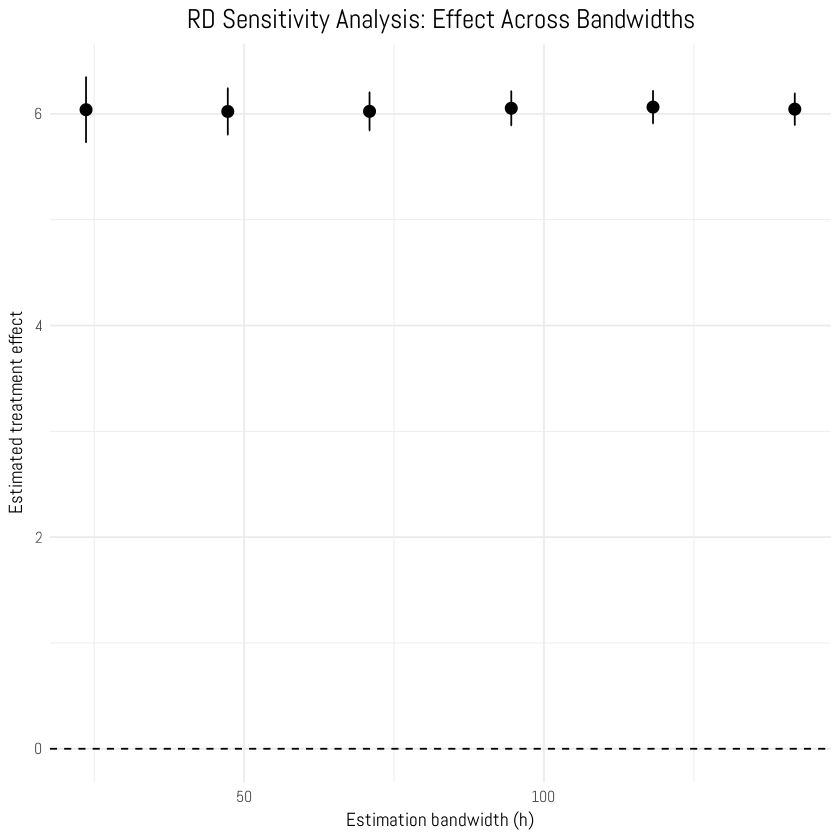

In [ ]:
plot_rd_sensitivity <- function(results) {
  ggplot(results, aes(x = h, y = estimate)) +
    geom_point(size = 3, color = "black") +
    geom_errorbar(aes(ymin = ci_lower, ymax = ci_upper), width = 0.2, color = "black") +
    geom_hline(yintercept = 0, linetype = "dashed", color = "black") +
    scale_x_continuous(name = "Estimation bandwidth (h)") +
    scale_y_continuous(name = "Estimated treatment effect") +
    ggtitle("RD Sensitivity Analysis: Effect Across Bandwidths") +
    theme_minimal() +
    theme(
      plot.title = element_text(hjust = 0.5, size = 20, face = "bold", family = "abel"),
      axis.title.x = element_text(size = 14, face = "bold", family = "abel"),
      axis.title.y = element_text(size = 14, face = "bold", family = "abel"),
      legend.position = "top",
      legend.title = element_text(size = 14, face = "bold", family = "abel"),
      legend.text = element_text(size = 12, family = "abel"),
      axis.text.x = element_text(size = 12, family = "abel"),
      axis.text.y = element_text(size = 12, family = "abel")
    )
}

plot_rd_sensitivity(rd_res$sensitivity)

## Testing Assumptions

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Testing%20Assumptions.png)

### Local Linearity

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Local%20Linearity.png)

rdrobust fits a local linear model within a small bandwidth around the cutoff.

It does not have to be linear globally the entire sample, just locally around the cutoff.

The linearity locally can be tested by changing p=1 (linear) to p=2 (polynomial) in the rdrobust function:

In [ ]:
rd_res <- rdrobust(y = df$addtl_orders_first_year, x = df$first_order_amount, c = cutoff,p=2)
summary(rd_res)

Sharp RD estimates using local polynomial regression.

Number of Obs.                74632
BW type                       mserd
Kernel                   Triangular
VCE method                       NN

Number of Obs.                37249        37383
Eff. Number of Obs.           16360        17021
Order est. (p)                    2            2
Order bias  (q)                   3            3
BW est. (h)                  20.348       20.348
BW bias (b)                  29.487       29.487
rho (h/b)                     0.690        0.690
Unique Obs.                   37249        37383

                   Point    Robust Inference
                Estimate         z     P>|z|      [ 95% C.I. ]       
---------------------------------------------------------------------
     RD Effect     5.867    25.354     0.000     [5.363 , 6.262]     


rdplot for p=1 (linear):

In [ ]:
out_p1 <- rdplot(y = df$addtl_orders_first_year, x = df$first_order_amount, c = cutoff,
      binselect = "esmv", kernel = "triangular", p=1,
      col.dots = "black",
      col.lines = "darkslategray3", hide=TRUE)


Plot model with p=1 (linear) to assess fit:

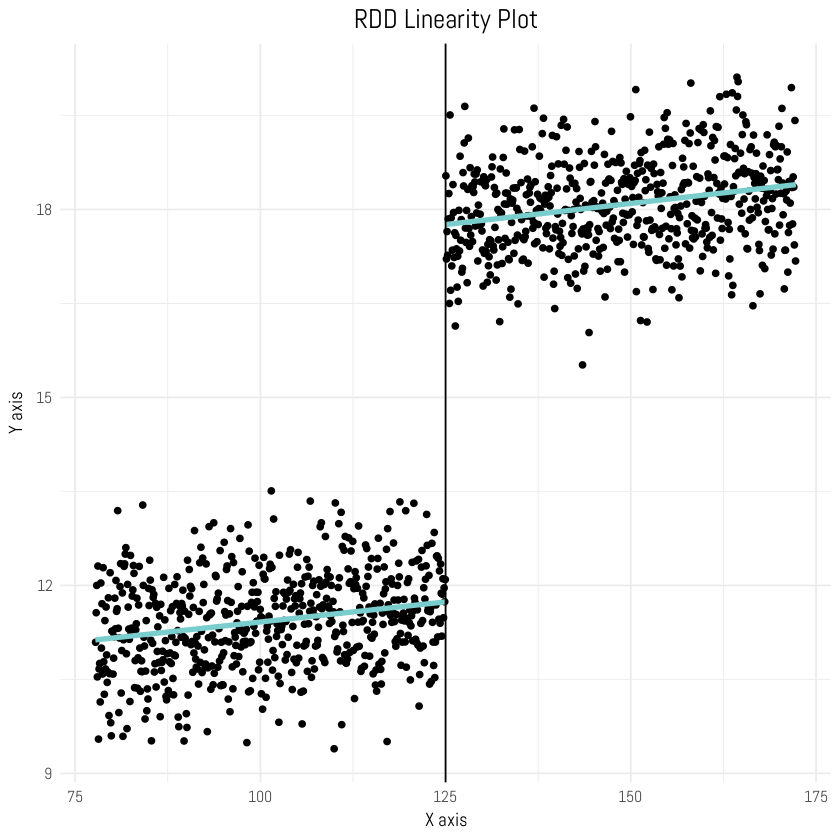

In [ ]:
font_add_google("Abel", "abel")
showtext_auto()

out_p1$rdplot$layers[[2]]$aes_params$size <- 1.5  # left regression line
out_p1$rdplot$layers[[3]]$aes_params$size <- 1.5  # right regression line

out_p1$rdplot +
  theme_minimal() +
  theme(
    text = element_text(family = "abel"),
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
    axis.title.x = element_text(size = 14, face = "bold"),
    axis.title.y = element_text(size = 14, face = "bold"),
    axis.text = element_text(size = 12)
  ) +
  ggtitle("RDD Linearity Plot")


rdplot with p=2 (polynomial):

In [ ]:
out_p2 <- rdplot(y = df$addtl_orders_first_year, x = df$first_order_amount, c = cutoff,
      binselect = "esmv", kernel = "triangular", p=2,
      col.dots = "black",   # dot color
      col.lines = "darkslategray3", hide=TRUE)    # regression line color

Plot model with p=2 (polynomial) to assess fit:

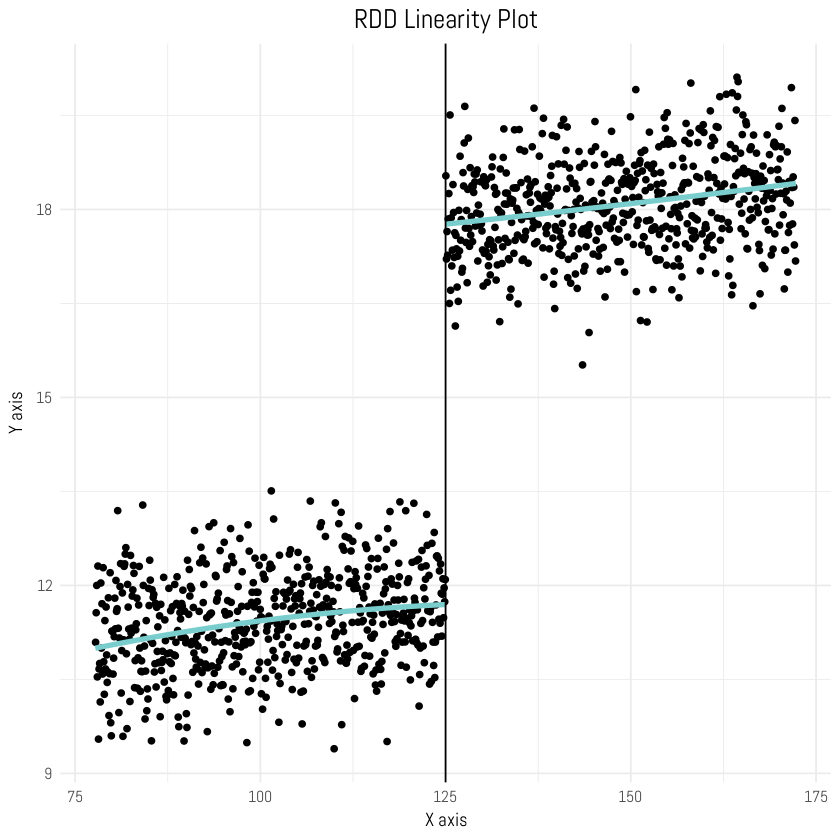

In [ ]:
font_add_google("Abel", "abel")
showtext_auto()

out_p2$rdplot$layers[[2]]$aes_params$size <- 1.5  # left regression line
out_p2$rdplot$layers[[3]]$aes_params$size <- 1.5  # right regression line

out_p2$rdplot +
  theme_minimal() +
  theme(
    text = element_text(family = "abel"),
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
    axis.title.x = element_text(size = 14, face = "bold"),
    axis.title.y = element_text(size = 14, face = "bold"),
    axis.text = element_text(size = 12)
  ) +
  ggtitle("RDD Linearity Plot")

The model shows a very linear appearance in both, and therefore fits a linear model well, validating the local linearity assumption. This is also tested with rdrobust further below.

### Balance Test

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Balance%20Test.png)

A balance test verifies that customers just above / below the cutoff are similar in their traits. There is no strong evidence (p-value=0.40) that the age for the group that had free shipping on their first order is different than the group that did not, shown by no significance on the first_order_free_shippingyes coefficient:

In [ ]:
balance_test_age <- lm(age ~ first_order_amount + first_order_free_shipping + first_order_amount:first_order_free_shipping, data = df)
summary(balance_test_age)


Call:
lm(formula = age ~ first_order_amount + first_order_free_shipping + 
    first_order_amount:first_order_free_shipping, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-28.8458 -14.4937   0.1709  14.5542  28.6880 

Coefficients:
                                                 Estimate Std. Error t value
(Intercept)                                     45.987895   0.652188  70.513
first_order_amount                               0.004168   0.006354   0.656
first_order_free_shippingyes                    -0.961620   1.151474  -0.835
first_order_amount:first_order_free_shippingyes  0.006401   0.009012   0.710
                                                Pr(>|t|)    
(Intercept)                                       <2e-16 ***
first_order_amount                                 0.512    
first_order_free_shippingyes                       0.404    
first_order_amount:first_order_free_shippingyes    0.478    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘

This is also demonstrated by almost identical boxplots for the distribution of the age, where the median and Q1 are the same and the Q3 is very similar:

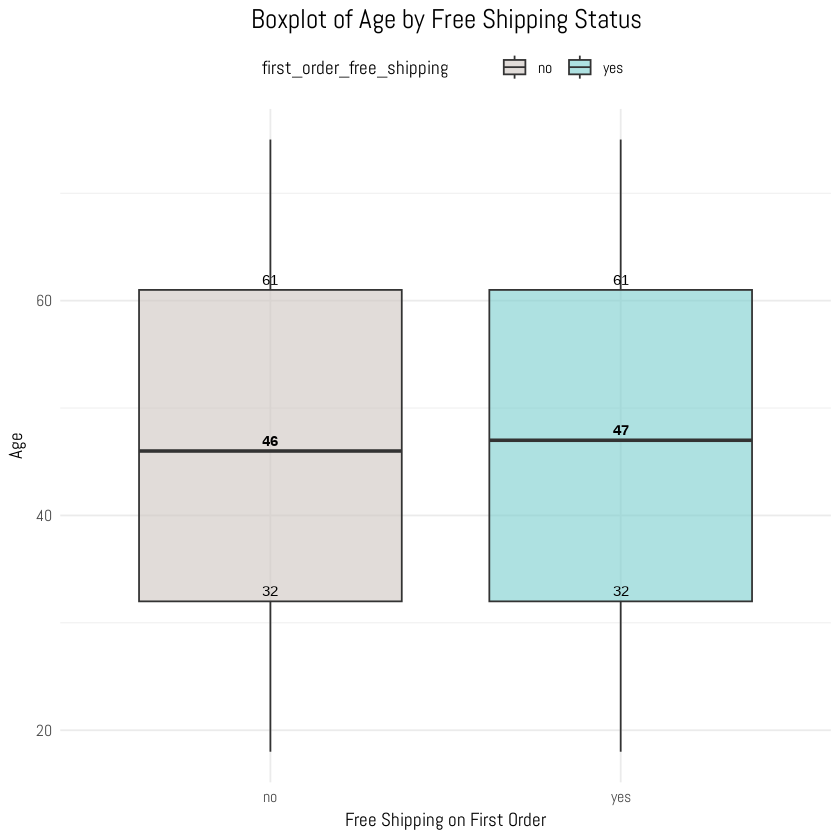

In [ ]:
# Compute quartiles
quartiles_df <- df %>%
  group_by(first_order_free_shipping) %>%
  summarise(
    Q1 = quantile(age, 0.25),
    Median = quantile(age, 0.5),
    Q3 = quantile(age, 0.75)
  )

# Plot with quartile labels
ggplot(df, aes(x = first_order_free_shipping, y = age, fill = first_order_free_shipping)) +
  geom_boxplot(alpha = 0.6) +
  scale_fill_manual(values = c("no" = "seashell3", "yes" = "darkslategray3")) +
  geom_text(data = quartiles_df, aes(x = first_order_free_shipping, y = Q1, label = round(Q1, 1)), vjust = -0.5) +
  geom_text(data = quartiles_df, aes(x = first_order_free_shipping, y = Median, label = round(Median, 1)), vjust = -0.5, fontface = "bold") +
  geom_text(data = quartiles_df, aes(x = first_order_free_shipping, y = Q3, label = round(Q3, 1)), vjust = -0.5) +
  labs(title = "Boxplot of Age by Free Shipping Status",
       x = "Free Shipping on First Order", y = "Age") +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold", family = "abel"),
    axis.title.x = element_text(size = 14, face = "bold", family = "abel"),
    axis.title.y = element_text(size = 14, face = "bold", family = "abel"),
    legend.position = "top",
    legend.title = element_text(size = 14, face = "bold", family = "abel"),
    legend.text = element_text(size = 12, family = "abel"),
    axis.text.x = element_text(size = 12, family = "abel"),
    axis.text.y = element_text(size = 12, family = "abel")
  )

Plot distributions (with density plot) of age for each shipping group to show their similarity:

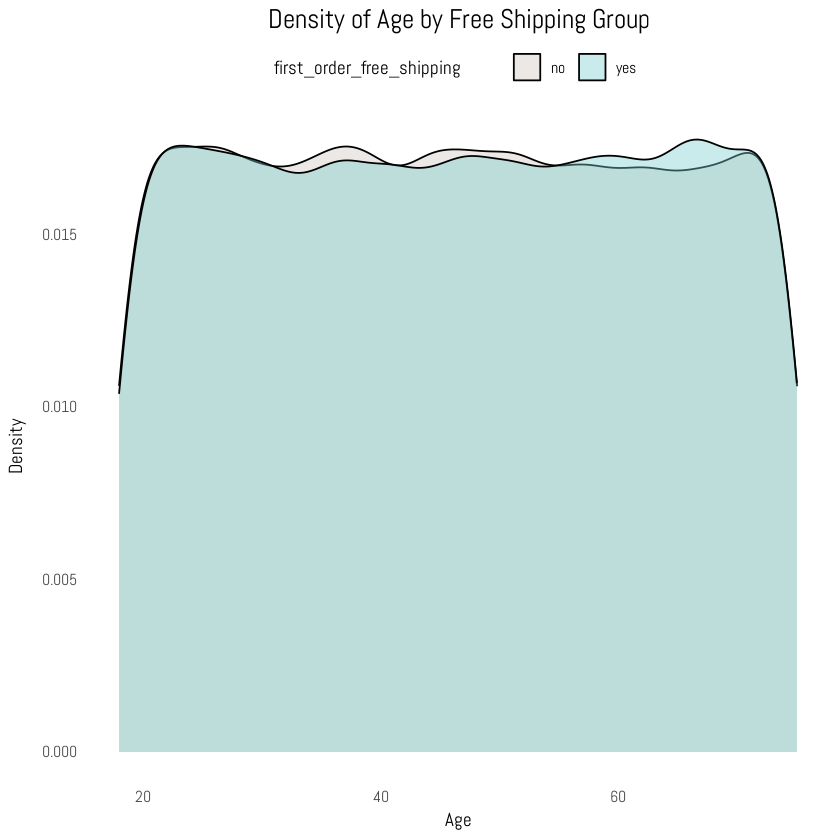

In [ ]:
ggplot(df, aes(x = age, fill = first_order_free_shipping)) +
  geom_density(alpha = 0.4) +
  labs(title = "Density of Age by Free Shipping Group",
       x = "Age", y = "Density") +
  scale_fill_manual(values = c("seashell3", "darkslategray3")) +
  theme_minimal() +
theme(panel.grid.major = element_blank(),
      panel.grid.minor = element_blank())  +
theme(
  plot.title = element_text(hjust = 0.5, size = 20, face = "bold", family = "abel"),
  axis.title.x = element_text(size = 14, face = "bold", family = "abel"),
  axis.title.y = element_text(size = 14, face = "bold", family = "abel"),
  legend.position = "top",
  legend.title = element_text(size = 14, face = "bold", family = "abel"),
  legend.text = element_text(size = 12, family = "abel"),
  axis.text.x = element_text(size = 12, family = "abel"),
  axis.text.y = element_text(size = 12, family = "abel")
)

Plot of age vs. running variable to show that there is no discontinuity in age at the cutoff:

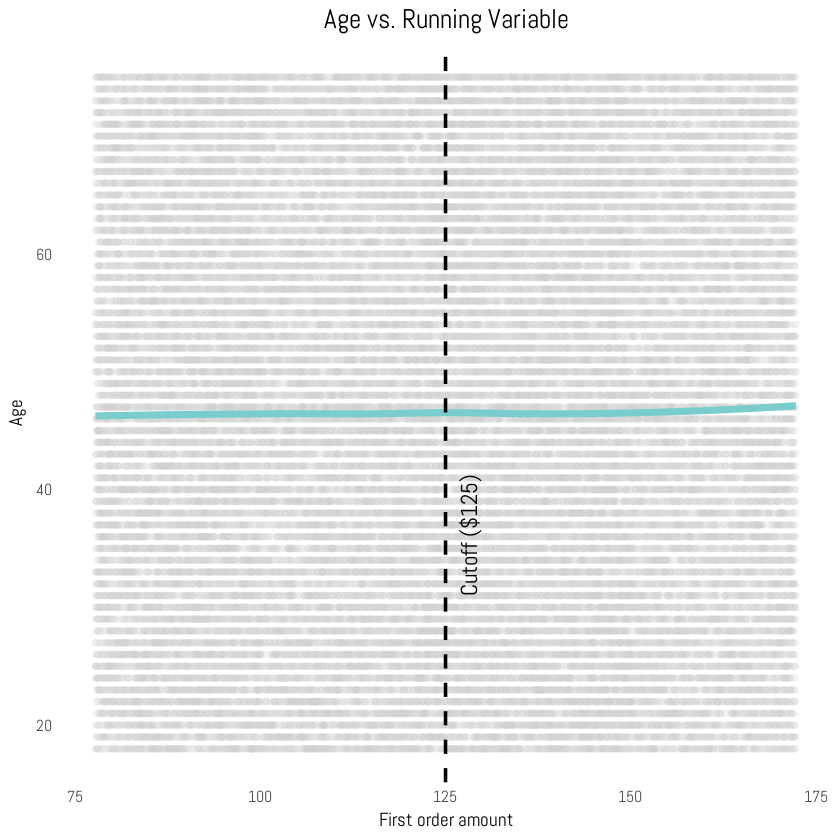

In [ ]:
  ggplot(df, aes(x = first_order_amount, y = age)) +
    geom_point(alpha = 0.1, color = "lightgrey") +  # faded light grey points
    geom_smooth(method = "loess", formula = y ~ x, se = FALSE, color = "darkslategray3", linewidth = 2) +  # thick dark line
    geom_vline(xintercept = cutoff, linetype = "dashed", color = "black", linewidth = 1) +
    labs(
      title = "Age vs. Running Variable",
      x = "First order amount",
      y = "Age"
    ) +
    theme_minimal() +
    annotate(
      "text", x = cutoff, y = max(df$y, na.rm = TRUE), label = "Cutoff ($125)", angle = 90,
      vjust = 2, hjust = 0, size = 6, family = "abel", fontface = "bold"
    ) +
    theme(panel.grid.major = element_blank(),
          panel.grid.minor = element_blank()) +
    theme(
      plot.title = element_text(hjust = 0.5, size = 20, face = "bold", family = "abel"),
      axis.title.x = element_text(size = 14, face = "bold", family = "abel"),
      axis.title.y = element_text(size = 14, face = "bold", family = "abel"),
      legend.position = "top",
      legend.title = element_text(size = 14, face = "bold", family = "abel"),
      legend.text = element_text(size = 12, family = "abel"),
      axis.text.x = element_text(size = 12, family = "abel"),
      axis.text.y = element_text(size = 12, family = "abel")
    )

### McCrary Test

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/McCrary%20Test.png)

The McCrary test is performed to check for manipulation or “bunching” at the cutoff. It uses local polynomial density to smoothly estimate the density in that area.

The RDD assumes users are as-good-as-randomly assigned near the cutoff. Bunching violates this assumption slightly because users around the cutoff are not exactly comparable. There might be differences in the users who manipulate the running variable vs. those who don't.

rddensity() automatically calculates the bandwidths that should go into the McCrary plot, which are different from the rdrobust() bandwidths. rdplotdensity() uses them to define the x-axis window around the cutoff.

If the test shows a sharp increase in observations right at the cutoff, it violates the assumptions of RDD, as the cutoff is not quasi-random. If it shows a drop after cutoff, which it appears to, it is less of an issue for manipulation, as it shows that fewer people meet the threshold, which can be consistent with normal user behavior.



In [ ]:
x <- df$first_order_amount

# McCrary density discontinuity test
rdd_out <- rddensity(x, c = cutoff)

summary(rdd_out)

# Optimal bandwidths (left & right) for density estimation
rdd_out$h


Manipulation testing using local polynomial density estimation.

Number of obs =       74632
Model =               unrestricted
Kernel =              triangular
BW method =           estimated
VCE method =          jackknife

c = 125               Left of c           Right of c          
Number of obs         37249               37383               
Eff. Number of obs    8551                6148                
Order est. (p)        2                   2                   
Order bias (q)        3                   3                   
BW est. (h)           10.321              7.296               

Method                T                   P > |T|             
Robust                -1.3472             0.1779              


P-values of binomial tests (H0: p=0.5).

Window Length / 2          <c     >=c    P>|T|
0.029                      22      20    0.8776
0.058                      50      39    0.2891
0.087                      76      64    0.3526
0.116                     108     

$left
[1] 10.32085

$right
[1] 7.296157

"Method Robust":
In the output above, the "Method Robust" section shows the McCrary test statistic, computed using a local polynomial density estimator at the cutoff, with robust standard errors. The p-value, which is insignficant here (0.1779), indicates no significant discontinuity in the density at the cutoff. This means the distribution of observations just below vs. just above the cutoff do not differ significantly, as the null hypothesis that there is no manipulation is not rejected. This is based on a smoothed estimate using all data in the selected bandwidth ("h") around the cutoff (10 dollars for left bandwidth and 7 dollars for right bandwidth around the 125 dollar cutoff).

Run rdplotdensity to get a density plot:

In [ ]:
densityplot <- rdplotdensity(
  rdd_out, x,
  plotRange = c(cutoff - rdd_out$hl, cutoff + rdd_out$hr),
  plotN = 25, noPlot = TRUE
)

Extract the plot from the output:

In [ ]:
densityplot<-densityplot$Estplot

The densityplot is a ggplot object:

In [ ]:
class(densityplot)

[1] "ggplot2::ggplot" "ggplot"          "ggplot2::gg"     "S7_object"      
[5] "gg"

Format and show densityplot for McCrary test:

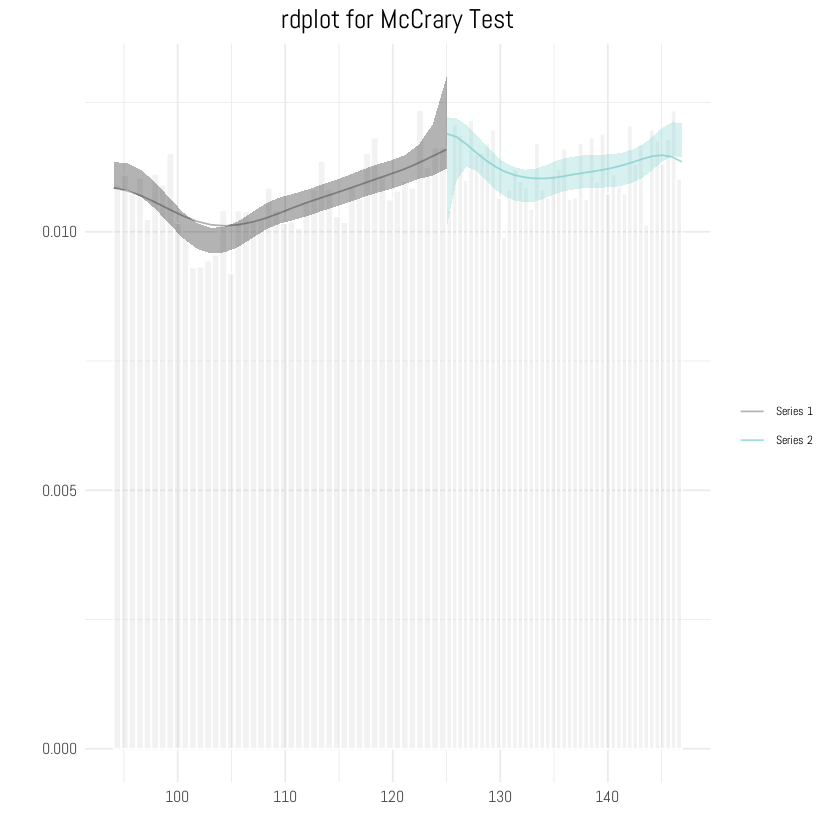

In [ ]:
# bars
densityplot$layers[[1]]$aes_params$fill <- "gray"      # interior color
densityplot$layers[[1]]$aes_params$color <- "black"    # border color

# ci
densityplot$layers[[2]]$aes_params$fill <- "black"
densityplot$layers[[2]]$aes_params$alpha <- 0.3

# line 1
densityplot$layers[[3]]$aes_params$colour <- "black"
densityplot$layers[[3]]$aes_params$alpha <- 0.3

# ci
densityplot$layers[[4]]$aes_params$fill <- "darkslategray3"
densityplot$layers[[4]]$aes_params$alpha <- 0.3

# line 2
densityplot$layers[[5]]$aes_params$colour <- "darkslategray3"
densityplot$layers[[5]]$aes_params$alpha <- 0.7


font_add_google("Abel", "abel")
showtext_auto()

densityplot +
  theme_minimal() +
  theme(
    text = element_text(family = "abel"),
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
    axis.title.x = element_text(size = 14, face = "bold"),
    axis.title.y = element_text(size = 14, face = "bold"),
    axis.text = element_text(size = 12)
  ) +
  ggtitle("rdplot for McCrary Test")


#Results Summary

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Results%20Summary.png)

Based on the regression discontinuity analysis, there was a significant causal effect of the treatment (receiving free shipping on first order) on the outcome (additional orders in their first year). It suggests that if a customer receives free shipping on their first order, they will order ~6x more on average in their first year. This result is valid based on the robustness checks.


#Recommendation

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Recommendation.png)

Based on the results, I recommend implementing a policy for free shipping on ALL first orders, given its impact on future orders.